<a href="https://colab.research.google.com/github/planlane/llm_advanced_s1/blob/main/session1b_tokenization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JeremieJakubowicz/xhec-advanced-ai-2026/blob/main/Session1/Session1b-Tokenization.ipynb)

# Session 1 (part B) — Tokenization: from letters to actions

**Advanced AI: Language Models & Agents** · X-HEC · Fall 2026 · Author: Jérémie Jakubowicz

Part A ended on a dilemma: characters are too small a unit, words are too big a unit. This notebook is about the unit actually used by every modern language model, the **token**, and it makes a claim that will structure the whole course:

> **Everything a language model does, it does by emitting tokens.** Words, code, numbers, a change of speaker, a call to a tool, the opening of a "thinking" scratchpad: all of it is tokens. Understanding the vocabulary is understanding what the model *can* do.

**What you will take away**

1. How a sub-word vocabulary is *learned* from data (Byte-Pair Encoding), and why it is a compression algorithm.
2. Why tokenization decides the **cost**, the **context length** and the **fairness across languages** of a model, and why models are bad at counting letters and at arithmetic.
3. What **special tokens** are, and how the same mechanism encodes dialogue turns, tool calls (session 8), thinking (session 5) and images.

In [ ]:
# On Google Colab, run this cell first (about 30 seconds). transformers, pandas and matplotlib are preinstalled there.
# Locally, see the README of this folder for the full list of dependencies.
%pip install -q tiktoken tokenizers "mistral-common[sentencepiece]"

In [ ]:
import os, re, json, random, urllib.request, warnings
from collections import Counter, defaultdict
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt

DATA_URL = "https://raw.githubusercontent.com/JeremieJakubowicz/xhec-advanced-ai-2026/main/data/hugotexts.txt"

def load_corpus(path="hugotexts.txt"):
    """Download the corpus (14 MB) from the course's public GitHub repository, once, then read it."""
    if not os.path.exists(path):
        print("Downloading the corpus from GitHub...")
        urllib.request.urlretrieve(DATA_URL, path)
    return open(path, encoding="utf-8").read()

hugo = load_corpus()
print(f"{len(hugo):,} characters")

13,508,455 characters


## 1. Three ways to cut a text

The choice of unit is a choice of **vocabulary size** versus **sequence length**, with a third dimension that part A made visible: what happens on text the model has never seen.
Let us measure the three on Hugo, training on the first 90 % and testing on the last 10 %.

In [ ]:
split = int(0.9 * len(hugo))
train_text, test_text = hugo[:split], hugo[split:]

def oov_rate(train_units, test_units):
    """share of test units never seen in training (out-of-vocabulary)"""
    known = set(train_units)
    return sum(u not in known for u in test_units) / len(test_units)

rows = []
rows.append(dict(unit="characters", vocabulary=len(set(train_text)), sequence_length=len(train_text),
                 oov=oov_rate(train_text, test_text)))
tw, sw = train_text.split(), test_text.split()
rows.append(dict(unit="words", vocabulary=len(set(tw)), sequence_length=len(tw), oov=oov_rate(tw, sw)))

import tiktoken
gpt2 = tiktoken.get_encoding("gpt2")
tt, st = gpt2.encode(train_text), gpt2.encode(test_text)
rows.append(dict(unit="GPT-2 sub-word tokens", vocabulary=gpt2.n_vocab, sequence_length=len(tt), oov=oov_rate(tt, st)))

pd.DataFrame(rows).style.format({"vocabulary": "{:,}", "sequence_length": "{:,}", "oov": "{:.2%}"})

,unit,vocabulary,sequence_length,oov
0,characters,132,"12,157,609",0.00%
1,words,"170,442","1,988,855",7.34%
2,GPT-2 sub-word tokens,"50,257","4,778,551",0.12%


Words: 7 % of the test text is made of words *never seen* in training (names, rare inflections, accented variants, typos). For a word model, these are holes. Characters and sub-word tokens have essentially no holes: any string can be encoded from known pieces. Sub-word tokens get this **at a sequence length only 2.4× that of words**, instead of 6× for characters.

Where does this vocabulary come from? It is **learned from data**, by the simplest algorithm imaginable.

## 2. Byte-Pair Encoding, from scratch

BPE (Sennrich et al., 2016, borrowed from a 1994 compression algorithm) works like this:

1. Start with the characters as the vocabulary. Every word is a sequence of characters.
2. Count all adjacent pairs of symbols in the corpus. **Merge the most frequent pair** into a new symbol, add it to the vocabulary.
3. Repeat step 2 for a fixed number of merges (GPT-2: 50,000; Llama 3: 128,000).

That is all. Here is a compact implementation, trained on a small slice of Hugo so that we can watch the merges appear.

In [ ]:
def bpe_train(text, num_merges, log_every=None):
    words = Counter(text.split())
    vocab = {tuple(w) + ("</w>",): c for w, c in words.items()}   # </w> marks the end of a word
    merges = []
    for k in range(num_merges):
        pairs = Counter()
        for symbols, c in vocab.items():
            for pair in zip(symbols, symbols[1:]):
                pairs[pair] += c
        if not pairs:
            break
        best = max(pairs, key=pairs.get)
        merges.append(best)
        vocab = {merge_pair(symbols, best): c for symbols, c in vocab.items()}
        if log_every and k % log_every == 0:
            print(f"merge {k:3d}: {best[0]!r} + {best[1]!r} -> {''.join(best)!r}   ({pairs[best]:,} occurrences)")
    return merges

def merge_pair(symbols, pair):
    out, i = [], 0
    while i < len(symbols):
        if i < len(symbols) - 1 and (symbols[i], symbols[i + 1]) == pair:
            out.append(symbols[i] + symbols[i + 1]); i += 2
        else:
            out.append(symbols[i]); i += 1
    return tuple(out)

def bpe_encode(word, merges):
    symbols = tuple(word) + ("</w>",)
    for pair in merges:                 # apply the merges in the order they were learned
        symbols = merge_pair(symbols, pair)
    return symbols

sample = hugo[:200_000]
merges = bpe_train(sample, num_merges=150, log_every=10)

merge   0: 'e' + '</w>' -> 'e</w>'   (8,654 occurrences)
merge  10: 'a' + 'i' -> 'ai'   (1,990 occurrences)


merge  20: 'e' + 't' -> 'et'   (1,106 occurrences)
merge  30: 'u' + 'n' -> 'un'   (838 occurrences)


merge  40: 'ai' + 't</w>' -> 'ait</w>'   (664 occurrences)
merge  50: 'c' + 'h' -> 'ch'   (493 occurrences)


merge  60: 'e' + 'c' -> 'ec'   (423 occurrences)
merge  70: 's' + 'i' -> 'si'   (379 occurrences)


merge  80: 'eu' + 'r' -> 'eur'   (343 occurrences)
merge  90: 'r' + 'i' -> 'ri'   (291 occurrences)


merge 100: "'" + 'est</w>' -> "'est</w>"   (230 occurrences)
merge 110: 'em' + 'ent</w>' -> 'ement</w>'   (206 occurrences)


merge 120: 's' + 'e' -> 'se'   (193 occurrences)
merge 130: 's' + 'i</w>' -> 'si</w>'   (166 occurrences)


merge 140: 'a' + 'p' -> 'ap'   (155 occurrences)


The first merges are the most frequent letter pairs of French (`e</w>`, `es`, `le`, `de`, `en`, `qu`...). After a few hundred merges, whole frequent words are single tokens, and rare words are cut into pieces that are *also* pieces of other words: this is what lets a model share what it learns between *amour*, *amours* and *amoureux*.

In [ ]:
for k in [10, 50, 150]:
    print(f"after {k:3d} merges:", "  ".join("|".join(bpe_encode(w, merges[:k])) for w in ["bonjour", "amour", "amoureux", "constitutionnellement"]))

after  10 merges: b|on|j|ou|r|</w>  a|m|ou|r|</w>  a|m|ou|r|e|u|x|</w>  c|on|s|t|i|t|u|t|i|on|n|e|l|l|e|m|en|t</w>
after  50 merges: b|on|j|ou|r</w>  a|m|ou|r</w>  a|m|ou|r|eu|x|</w>  c|on|s|ti|t|u|ti|on|n|el|l|em|ent</w>
after 150 merges: b|on|j|ou|r</w>  am|ou|r</w>  am|our|eux</w>  con|s|ti|t|u|tion|n|el|l|ement</w>


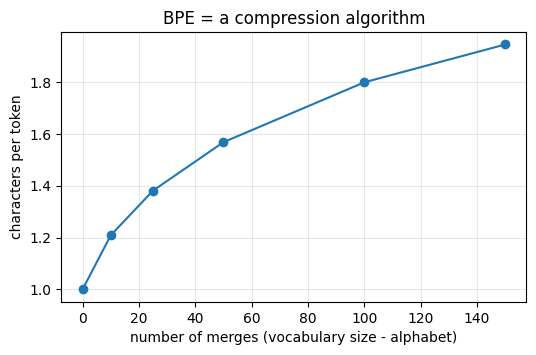

In [ ]:
# Tokenization is compression: chars per token as the number of merges grows
test_words = hugo[300_000:310_000].split()
xs, ys = [], []
for k in [0, 10, 25, 50, 100, 150]:
    n_tokens = sum(len(bpe_encode(w, merges[:k])) for w in test_words)
    xs.append(k); ys.append(sum(len(w) + 1 for w in test_words) / n_tokens)
plt.figure(figsize=(6, 3.5)); plt.plot(xs, ys, "o-"); plt.grid(alpha=.3)
plt.xlabel("number of merges (vocabulary size - alphabet)"); plt.ylabel("characters per token")
plt.title("BPE = a compression algorithm"); plt.show()

### 2.1 A real BPE tokenizer trained on Hugo

Our Python loop is slow. The `tokenizers` library (Hugging Face, written in Rust) trains the same algorithm on the whole corpus in a few seconds. Two differences with the toy version: it works on **bytes** rather than characters (so that *any* input, in any script, can be encoded with a 256-symbol alphabet), and it first splits the text with a regular expression (the *pre-tokenizer*) so that merges never cross a space or mix letters and punctuation.

In [ ]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

hugo_tok = Tokenizer(models.BPE())
hugo_tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
hugo_tok.decoder = decoders.ByteLevel()
trainer = trainers.BpeTrainer(vocab_size=8_000, special_tokens=["<|endoftext|>"],
                              initial_alphabet=pre_tokenizers.ByteLevel.alphabet(), show_progress=False)
hugo_tok.train_from_iterator((hugo[i:i + 100_000] for i in range(0, len(hugo), 100_000)), trainer)

phrase = "Les miserables sont les enfants de la misere et de l'ignorance."
print("Hugo-BPE (8k) :", hugo_tok.encode(phrase).tokens)
print("GPT-2   (50k) :", [gpt2.decode([t]) for t in gpt2.encode(phrase)])
print()
for name, n in [("Hugo-BPE (8k)", len(hugo_tok.encode(test_text[:200_000]).ids)), ("GPT-2 (50k)", len(gpt2.encode(test_text[:200_000])))]:
    print(f"{name:14} {200_000 / n:.2f} characters per token on unseen Hugo")

Hugo-BPE (8k) : ['Les', 'Ġmis', 'er', 'ables', 'Ġsont', 'Ġles', 'Ġenfants', 'Ġde', 'Ġla', 'Ġmisere', 'Ġet', 'Ġde', 'Ġl', "'", 'ignorance', '.']
GPT-2   (50k) : ['Les', ' miser', 'ables', ' s', 'ont', ' les', ' en', 'f', 'ants', ' de', ' la', ' mis', 'ere', ' et', ' de', ' l', "'", 'ign', 'or', 'ance', '.']

Hugo-BPE (8k)  3.35 characters per token on unseen Hugo
GPT-2 (50k)    2.50 characters per token on unseen Hugo


A tokenizer with a vocabulary **six times smaller**, trained on French, compresses French *better* than GPT-2, whose vocabulary was learned on mostly English web text. **A tokenizer is a snapshot of its training data.** That has consequences.

## 3. The tokenizer zoo

Let us line up six real tokenizers: three from OpenAI (GPT-2, GPT-4, GPT-4o), one from Alibaba (Qwen3), two from Mistral (the 32k SentencePiece one and *Tekken*, 131k).
We wrap them in a common interface: `encode(text) -> ids`, `pieces(text) -> strings`.

In [ ]:
from transformers import AutoTokenizer
from mistral_common.tokens.tokenizers.mistral import MistralTokenizer

class Tok:
    def __init__(self, name, encode, decode_one, vocab, year):
        self.name, self.encode, self.decode_one, self.vocab, self.year = name, encode, decode_one, vocab, year
    def pieces(self, text):
        return [self.decode_one(i) for i in self.encode(text)]

def tiktoken_tok(name, label, year):
    e = tiktoken.get_encoding(name)
    return Tok(label, lambda s: e.encode(s, disallowed_special=()), lambda i: e.decode_single_token_bytes(i).decode("utf-8", "replace"), e.n_vocab, year)

qwen = AutoTokenizer.from_pretrained("Qwen/Qwen3-0.6B")
def hf_tok(hf, label, year):
    return Tok(label, lambda s: hf.encode(s, add_special_tokens=False), lambda i: hf.decode([i]), len(hf), year)

def mistral_tok(mt, label, year):
    it = mt.instruct_tokenizer.tokenizer
    return Tok(label, lambda s: it.encode(s, bos=False, eos=False), lambda i: it.id_to_piece(i).replace("▁", " "), it.n_words, year)

ZOO = [tiktoken_tok("gpt2", "GPT-2", 2019),
       tiktoken_tok("cl100k_base", "GPT-4", 2023),
       tiktoken_tok("o200k_base", "GPT-4o", 2024),
       mistral_tok(MistralTokenizer.v3(), "Mistral v3 (SentencePiece)", 2024),
       mistral_tok(MistralTokenizer.v3(is_tekken=True), "Mistral Tekken", 2024),
       hf_tok(qwen, "Qwen3", 2025)]

pd.DataFrame([dict(tokenizer=t.name, year=t.year, vocabulary=t.vocab) for t in ZOO]).style.format({"vocabulary": "{:,}"})

,tokenizer,year,vocabulary
0,GPT-2,2019,"50,257"
1,GPT-4,2023,"100,277"
2,GPT-4o,2024,"200,019"
3,Mistral v3 (SentencePiece),2024,"32,768"
4,Mistral Tekken,2024,"131,072"
5,Qwen3,2025,"151,669"


In [ ]:
from IPython.display import HTML, display

COLORS = ["#cfe8ff", "#ffe0b3", "#d4f5d4", "#f9d0e5", "#e6d9ff", "#fff3b0"]

def show_tokens(tok, text):
    """Render the tokens of `text` as coloured spans (spaces and newlines made visible)."""
    spans = []
    for k, piece in enumerate(tok.pieces(text)):
        visible = piece.replace(" ", "␣").replace("\n", "⏎\n")
        spans.append(f'<span style="background:{COLORS[k % len(COLORS)]};padding:1px 2px;border-radius:3px;white-space:pre">{visible}</span>')
    n = len(tok.encode(text))
    display(HTML(f'<div style="font-family:monospace;font-size:14px;line-height:1.9"><b>{tok.name}</b> · {n} tokens<br>{"".join(spans)}</div>'))

for t in ZOO:
    show_tokens(t, "Tokenization is not what you think. La tokenisation n'est pas ce que vous croyez.")

Same sentence, six vocabularies, six different cuts. The English half is mostly whole words with the space attached in front (` not`, ` what`); the French half is cut into more pieces. Let us make that systematic.

### 3.1 Not all languages cost the same

In [ ]:
TEXTS = {
    "English":  "It was the best of times, it was the worst of times, it was the age of wisdom, it was the age of foolishness, it was the epoch of belief, it was the epoch of incredulity.",
    "French":   "C'était le meilleur des temps, c'était le pire des temps, c'était l'âge de la sagesse, c'était l'âge de la folie, c'était l'époque de la foi, c'était l'époque de l'incrédulité.",
    "German":   "Es war die beste Zeit, es war die schlimmste Zeit, es war das Zeitalter der Weisheit, es war das Zeitalter der Torheit, es war die Epoche des Glaubens.",
    "Chinese":  "那是最美好的时代，那是最糟糕的时代；那是智慧的年头，那是愚昧的年头；那是信仰的时期，那是怀疑的时期。",
    "Python":   "def fibonacci(n):\n    if n < 2:\n        return n\n    return fibonacci(n - 1) + fibonacci(n - 2)\n\nprint([fibonacci(i) for i in range(10)])",
    "JSON":     '{"customer_id": 48213, "items": [{"sku": "A-1027", "qty": 2, "price": 19.99}], "currency": "EUR", "paid": true}',
}

table = pd.DataFrame({t.name: {lang: len(t.encode(text)) for lang, text in TEXTS.items()} for t in ZOO})
chars = pd.Series({lang: len(text) for lang, text in TEXTS.items()})
per100 = table.div(chars, axis=0) * 100
per100.round(1).style.background_gradient(cmap="Reds", axis=None).set_caption("tokens per 100 characters")

,GPT-2,GPT-4,GPT-4o,Mistral v3 (SentencePiece),Mistral Tekken,Qwen3
English,26.500000,26.500000,26.500000,26.500000,26.500000,26.500000
French,46.600000,35.200000,29.000000,39.800000,28.400000,35.200000
German,33.100000,31.800000,27.800000,31.100000,28.500000,31.800000
Chinese,204.000000,136.000000,90.000000,134.000000,86.000000,66.000000
Python,48.900000,31.400000,31.400000,44.500000,35.000000,32.100000
JSON,43.200000,40.500000,40.500000,52.300000,49.500000,46.800000


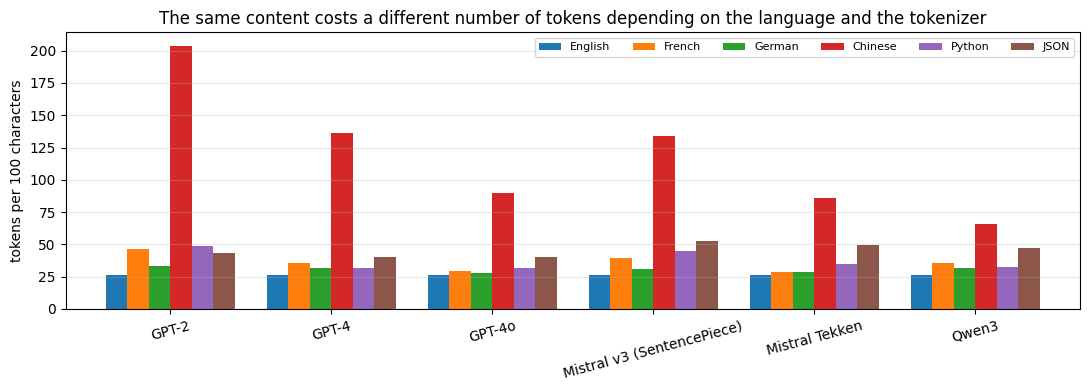

The same sentence in French costs, per word, this many times its English version:
GPT-2                         2.26
GPT-4                         1.71
GPT-4o                        1.41
Mistral v3 (SentencePiece)    1.93
Mistral Tekken                1.38
Qwen3                         1.71


,GPT-2,GPT-4,GPT-4o,Mistral v3 (SentencePiece),Mistral Tekken,Qwen3
English,1.250000,1.250000,1.250000,1.250000,1.250000,1.250000
French,2.830000,2.140000,1.760000,2.410000,1.720000,2.140000
German,1.790000,1.710000,1.500000,1.680000,1.540000,1.710000


In [ ]:
ax = per100.T.plot.bar(figsize=(11, 4), rot=15, width=.8)
ax.set_ylabel("tokens per 100 characters"); ax.grid(axis="y", alpha=.3); ax.legend(ncol=6, fontsize=8)
ax.set_title("The same content costs a different number of tokens depending on the language and the tokenizer")
plt.tight_layout(); plt.show()

fertility = pd.DataFrame({t.name: {lang: len(t.encode(TEXTS[lang])) / len(TEXTS[lang].split()) for lang in ["English", "French", "German"]} for t in ZOO})
print("The same sentence in French costs, per word, this many times its English version:")
print((fertility.loc["French"] / fertility.loc["English"]).round(2).to_string())
fertility.round(2).style.set_caption("fertility = tokens per word")

**Why this matters (and not only to linguists).**

* **Cost.** APIs bill per token. On GPT-2's vocabulary the French sentence costs more than twice its English twin, per word; newer, bigger vocabularies (GPT-4o, Qwen3) narrow the gap but do not close it, and Mistral's Tekken, explicitly built for European languages, is the most frugal on French. Chinese, counted per character, is the most expensive column of the table on every tokenizer.
* **Context window.** A model that reads 128k *tokens* reads fewer *pages* of French than of English.
* **Speed.** Generation happens one token at a time. More tokens per sentence means a slower model.
* **Quality.** A language cut into small, meaningless pieces is harder to model: each token carries less information and the model must reassemble the pieces. The "tokenization tax" is one of the reasons why LLMs are better in English.

### 3.2 Code: the whitespace problem

Look at the Python column above: GPT-2 needs about 60 % more tokens than GPT-4 for the same code. Here is why.

In [ ]:
snippet = "def fibonacci(n):\n    if n < 2:\n        return n\n    return fibonacci(n - 1) + fibonacci(n - 2)"
for t in [ZOO[0], ZOO[1], ZOO[4]]:
    show_tokens(t, snippet)

GPT-2 (2019) spends one token per space of indentation: a deeply nested Python block is a waste of context, and the model has to count spaces to produce valid code. From GPT-4's tokenizer on, runs of spaces are single tokens: this was a deliberate change driven by the importance of code (the [tiktoken](https://github.com/openai/tiktoken) pre-tokenization regex was rewritten for it). *A vocabulary is a product decision.*

### 3.3 Numbers: why LLMs are bad at arithmetic

In [ ]:
numbers = ["12345678", "3.14159", "1,234,567", "2024-01-15", "€1,234.56"]
pd.DataFrame({t.name: {n: " | ".join(t.pieces(n)) for n in numbers} for t in ZOO})

,GPT-2,GPT-4,GPT-4o,Mistral v3 (SentencePiece),Mistral Tekken,Qwen3
12345678,123 | 45 | 678,123 | 456 | 78,123 | 456 | 78,| 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8,1 | 2 | 3 | 4 | 5 | 6 | 7 | 8,1 | 2 | 3 | 4 | 5 | 6 | 7 | 8
3.14159,3 | . | 14 | 159,3 | . | 141 | 59,3 | . | 141 | 59,| 3 | . | 1 | 4 | 1 | 5 | 9,3 | . | 1 | 4 | 1 | 5 | 9,3 | . | 1 | 4 | 1 | 5 | 9
"1,234,567","1 | , | 234 | , | 5 | 67","1 | , | 234 | , | 567","1 | , | 234 | , | 567","| 1 | , | 2 | 3 | 4 | , | 5 | 6 | 7","1 | , | 2 | 3 | 4 | , | 5 | 6 | 7","1 | , | 2 | 3 | 4 | , | 5 | 6 | 7"
2024-01-15,20 | 24 | - | 01 | - | 15,202 | 4 | - | 01 | - | 15,202 | 4 | - | 01 | - | 15,| 2 | 0 | 2 | 4 | - | 0 | 1 | - | 1 | 5,2 | 0 | 2 | 4 | - | 0 | 1 | - | 1 | 5,2 | 0 | 2 | 4 | - | 0 | 1 | - | 1 | 5
"€1,234.56","€ | 1 | , | 234 | . | 56","€ | 1 | , | 234 | . | 56","€ | 1 | , | 234 | . | 56","€ | 1 | , | 2 | 3 | 4 | . | 5 | 6","€ | 1 | , | 2 | 3 | 4 | . | 5 | 6","€ | 1 | , | 2 | 3 | 4 | . | 5 | 6"


Three different policies coexist:

* **GPT-2**: whatever BPE learned. `12345678` becomes `123|45|678`, and `12345679` may be cut elsewhere. Arithmetic on such tokens is a nightmare: the model never sees digits aligned.
* **GPT-4 and GPT-4o**: numbers are cut into chunks of *at most three digits*, left to right. Better, but `1234` becomes `123|4`, while the carries of addition propagate from the right.
* **Mistral (both) and Llama 3**: **one token per digit**. Slower, but every digit is visible, and arithmetic becomes learnable.

The famous *"how many r's in strawberry"* failure is the same phenomenon in the other direction: the model does not see letters, it sees tokens.

In [ ]:
for t in [ZOO[1], ZOO[4], ZOO[5]]:
    print(f"{t.name:28} strawberry -> {t.pieces('strawberry')}      Strawberry -> {t.pieces(' Strawberry')}")

GPT-4                        strawberry -> ['str', 'aw', 'berry']      Strawberry -> [' Strawberry']
Mistral Tekken               strawberry -> ['st', 'raw', 'berry']      Strawberry -> [' Straw', 'berry']
Qwen3                        strawberry -> ['str', 'aw', 'berry']      Strawberry -> [' Strawberry']


## 4. Special tokens: the vocabulary of *actions*

So far, tokens encode *text*. But look at the first entries of Mistral's vocabulary:

In [ ]:
tekken = MistralTokenizer.v3(is_tekken=True).instruct_tokenizer.tokenizer
print("Mistral Tekken, ids 0 to 19:", [tekken.id_to_piece(i) for i in range(20)])
print()
print("Qwen3, special tokens:", list(qwen.get_added_vocab().keys()))
print()
print("GPT-4 (cl100k), special tokens:", sorted(tiktoken.get_encoding("cl100k_base").special_tokens_set))

Mistral Tekken, ids 0 to 19: ['<unk>', '<s>', '</s>', '[INST]', '[/INST]', '[AVAILABLE_TOOLS]', '[/AVAILABLE_TOOLS]', '[TOOL_RESULTS]', '[/TOOL_RESULTS]', '[TOOL_CALLS]', '[IMG]', '<pad>', '[IMG_BREAK]', '[IMG_END]', '[PREFIX]', '[MIDDLE]', '[SUFFIX]', '[SYSTEM_PROMPT]', '[/SYSTEM_PROMPT]', '[TOOL_CONTENT]']

Qwen3, special tokens: ['<|endoftext|>', '<|im_start|>', '<|im_end|>', '<|object_ref_start|>', '<|object_ref_end|>', '<|box_start|>', '<|box_end|>', '<|quad_start|>', '<|quad_end|>', '<|vision_start|>', '<|vision_end|>', '<|vision_pad|>', '<|image_pad|>', '<|video_pad|>', '<tool_call>', '</tool_call>', '<|fim_prefix|>', '<|fim_middle|>', '<|fim_suffix|>', '<|fim_pad|>', '<|repo_name|>', '<|file_sep|>', '<tool_response>', '</tool_response>', '<think>', '</think>']

GPT-4 (cl100k), special tokens: ['<|endofprompt|>', '<|endoftext|>', '<|fim_middle|>', '<|fim_prefix|>', '<|fim_suffix|>']


None of these strings is text. They are **special tokens** (also called *control tokens*): ids reserved in the vocabulary that

* are **atomic**: they can never be produced by merging pieces of ordinary text, and are never cut into pieces;
* mark **structure** and **actions**: the end of a document, a change of speaker, an image, a call to a tool, the opening of a thinking scratchpad;
* are inserted by the **software around the model** (the *chat template*, the *harness*), and, for some of them, *emitted by the model itself* to act.

### 4.1 Atomic, and protected

If a user types the string `<think>` in a message, is it the special token? It must not be, otherwise anyone could hijack the structure of the conversation (*prompt injection*, session 10). Tokenizers handle this in two ways.

In [ ]:
print("Qwen3: '<|im_start|>' typed as text                    ->", qwen.encode("<|im_start|>", add_special_tokens=False))
print("Qwen3: the same string, with split_special_tokens=True ->", qwen.encode("<|im_start|>", add_special_tokens=False, split_special_tokens=True))
print("Qwen3: '<think>' typed as text                         ->", qwen.encode("<think>", add_special_tokens=False))
print("Qwen3: the same string, with split_special_tokens=True ->", qwen.encode("<think>", add_special_tokens=False, split_special_tokens=True),
      "  (Qwen3 registers <think> as an added token, but flags it special =", qwen.added_tokens_decoder[151667].special, ")")
print("Qwen3: '<think >' with a space, ordinary text          ->", qwen.encode("<think >", add_special_tokens=False))
print()
e = tiktoken.get_encoding("gpt2")
try:
    e.encode("Some text <|endoftext|> more text")
except ValueError as err:
    print("tiktoken refuses by default:", str(err)[:90], "...")
print("tiktoken, special token allowed explicitly:", e.encode("Some text <|endoftext|> more text", allowed_special={"<|endoftext|>"}))
print("tiktoken, treated as plain text            :", e.encode("Some text <|endoftext|> more text", disallowed_special=()))

Qwen3: '<|im_start|>' typed as text                    -> [151644]
Qwen3: the same string, with split_special_tokens=True -> [27, 91, 318, 4906, 91, 29]
Qwen3: '<think>' typed as text                         -> [151667]
Qwen3: the same string, with split_special_tokens=True -> [151667]   (Qwen3 registers <think> as an added token, but flags it special = False )
Qwen3: '<think >' with a space, ordinary text          -> [13708, 766, 861]

tiktoken refuses by default: Encountered text corresponding to disallowed special token '<|endoftext|>'.
If you want th ...
tiktoken, special token allowed explicitly: [4366, 2420, 220, 50256, 517, 2420]
tiktoken, treated as plain text            : [4366, 2420, 1279, 91, 437, 1659, 5239, 91, 29, 517, 2420]


Hugging Face tokenizers recognise the special string by default (convenient for building training data, dangerous for user input: pass `split_special_tokens=True` on anything a user typed). `tiktoken` refuses by default and forces the developer to choose. Either way: **the same characters, two different tokens, depending on who inserted them.**

Notice the nuance in the third and fourth lines: Qwen3 registers `<think>` as an *added* token but not as a *special* one, so the safety switch leaves it alone and a user who types `<think>` produces the real token. Whether that is a bug or a feature is a fair question for session 10.

### 4.2 The first action: stopping

Shannon's game never ends: there is no way to say "the text is finished". Our Markov generator in part A stopped after $n$ tokens or, in the 2025 version, at the first full stop, which was a hack. Every real language model has an **end-of-sequence** token. Emitting it is the first *action* a model learns: the decision to stop talking.

In [ ]:
print("GPT-2       <|endoftext|> =", gpt2.encode("<|endoftext|>", allowed_special="all"))
print("Mistral     <s> = 1, </s> = 2   (beginning and end of sequence)")
print("Qwen3       <|endoftext|> =", qwen.convert_tokens_to_ids("<|endoftext|>"), "  <|im_end|> =", qwen.convert_tokens_to_ids("<|im_end|>"), " (end of a turn)")

GPT-2       <|endoftext|> = [50256]
Mistral     <s> = 1, </s> = 2   (beginning and end of sequence)
Qwen3       <|endoftext|> = 151643   <|im_end|> = 151645  (end of a turn)


### 4.3 Turns: how a text model becomes a chat model

A base model completes text. ChatGPT-style dialogue is a **formatting convention** made of special tokens, on which the model is trained after pre-training (session 5). Here is what the model actually receives when you ask Qwen3 a question:

In [ ]:
messages = [{"role": "system", "content": "You are a concise assistant."},
            {"role": "user", "content": "Combien font 17 fois 23 ?"}]
rendered = qwen.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)
print(rendered)
print("---- as tokens:", len(qwen.encode(rendered, add_special_tokens=False)), "tokens, of which special:",
      [p for p in qwen.tokenize(rendered) if p in qwen.get_added_vocab()])

<|im_start|>system
You are a concise assistant.<|im_end|>
<|im_start|>user
Combien font 17 fois 23 ?<|im_end|>
<|im_start|>assistant
<think>

</think>


---- as tokens: 34 tokens, of which special: ['<|im_start|>', '<|im_end|>', '<|im_start|>', '<|im_end|>', '<|im_start|>', '<think>', '</think>']


`<|im_start|>user ... <|im_end|>` delimits a turn; the model is prompted with `<|im_start|>assistant\n` and generates until it emits `<|im_end|>`. The roles *system*, *user*, *assistant* are ordinary text after the special token, which is why they can be extended (Qwen also has *tool*).

Mistral uses another convention, `[INST] ... [/INST]`. Compare two generations of their template: the 2024 one (v3) folds the system prompt into the first user turn, the later one (v7) gives it dedicated tokens. **Templates are versioned like code**, and a model only understands the template it was trained with.

In [ ]:
from mistral_common.protocol.instruct.messages import UserMessage, SystemMessage, AssistantMessage, ToolMessage
from mistral_common.protocol.instruct.request import ChatCompletionRequest
from mistral_common.protocol.instruct.tool_calls import Tool, Function, ToolCall, FunctionCall

req = ChatCompletionRequest(messages=[SystemMessage(content="You are a concise assistant."),
                                      UserMessage(content="Combien font 17 fois 23 ?")])
mistral = MistralTokenizer.v3(is_tekken=True)
for label, tokenizer in [("Mistral template v3", mistral), ("Mistral template v7", MistralTokenizer.v7())]:
    encoded = tokenizer.encode_chat_completion(req)
    print(f"{label} ({len(encoded.tokens)} tokens):")
    print("   ", encoded.text.replace("▁", " ").replace("\n", "\n    "))

Mistral template v3 (20 tokens):
    <s>[INST]You are a concise assistant.
    
    Combien font 17 fois 23 ?[/INST]
Mistral template v7 (23 tokens):
    <s>[SYSTEM_PROMPT] You are a concise assistant.[/SYSTEM_PROMPT][INST] Combien font 17 fois 23 ?[/INST]


### 4.4 Actions: tool calls are tokens

Sessions 8 and 9 are about agents: models that *do* things (search the web, run code, book a meeting). Here is the whole secret, visible in the tokenizer. We declare a tool `get_weather`, the user asks a question, the model **emits** a call, the harness executes it and **inserts** the result.

In [ ]:
weather_tool = Tool(function=Function(
    name="get_weather", description="Current weather in a city",
    parameters={"type": "object", "properties": {"city": {"type": "string"}}, "required": ["city"]}))

conversation = ChatCompletionRequest(
    tools=[weather_tool],
    messages=[
        UserMessage(content="Quel temps fait-il a Paris ?"),
        AssistantMessage(content=None, tool_calls=[ToolCall(id="call0001a", function=FunctionCall(name="get_weather", arguments='{"city": "Paris"}'))]),
        ToolMessage(content='{"temp_c": 21, "sky": "sunny"}', tool_call_id="call0001a"),
    ])
encoded = mistral.encode_chat_completion(conversation)

text = encoded.text
for marker in ["[AVAILABLE_TOOLS]", "[/AVAILABLE_TOOLS]", "[INST]", "[/INST]", "[TOOL_CALLS]", "</s>", "[TOOL_RESULTS]", "[/TOOL_RESULTS]"]:
    text = text.replace(marker, f"\n  {marker} ")
print(text)

<s>
  [AVAILABLE_TOOLS] [{"type": "function", "function": {"name": "get_weather", "description": "Current weather in a city", "parameters": {"type": "object", "properties": {"city": {"type": "string"}}, "required": ["city"]}}}]
  [/AVAILABLE_TOOLS] 
  [INST] Quel temps fait-il a Paris ?
  [/INST] 
  [TOOL_CALLS] [{"name": "get_weather", "arguments": {"city": "Paris"}, "id": "call0001a"}]
  </s> 
  [TOOL_RESULTS] {"content": {"temp_c": 21, "sky": "sunny"}, "call_id": "call0001a"}
  [/TOOL_RESULTS] 


Read it as a script with two actors:

| who writes it                           | tokens                                                                                                                 |
| --------------------------------------- | ---------------------------------------------------------------------------------------------------------------------- |
| the harness (your code)                 | `<s>` `[AVAILABLE_TOOLS]` *the JSON schema of the tools* `[/AVAILABLE_TOOLS]` `[INST]` *the user's question* `[/INST]` |
| **the model**                           | `[TOOL_CALLS]` *a JSON with the function name and arguments* `</s>`                                                    |
| the harness, after running the function | `[TOOL_RESULTS]` *the function's output* `[/TOOL_RESULTS]`                                                             |
| **the model**                           | *the final answer in words* `</s>`                                                                                     |

The model never executes anything. It emits a special token that means *"I want to act"*, followed by ordinary tokens describing the action. The **harness** watches for that token, runs the function, and feeds the result back as more tokens. That loop is, quite literally, what an agent is. Qwen does the same with `<tool_call> ... </tool_call>` and `<tool_response>`; OpenAI and Anthropic models do it with tokens you never see because the API hides them.

### 4.5 Thinking: a scratchpad delimited by tokens

"Reasoning models" (OpenAI o-series, DeepSeek-R1, Qwen3, Claude with extended thinking) produce a long intermediate text before answering. Once more, the mechanism is two special tokens: `<think>` and `</think>`. Watch what Qwen3's template does when you *disable* thinking:

In [ ]:
q = [{"role": "user", "content": "Combien font 17 fois 23 ?"}]
print("thinking enabled :", repr(qwen.apply_chat_template(q, tokenize=False, add_generation_prompt=True, enable_thinking=True)[-40:]))
print("thinking disabled:", repr(qwen.apply_chat_template(q, tokenize=False, add_generation_prompt=True, enable_thinking=False)[-40:]))

thinking enabled : 'is 23 ?<|im_end|>\n<|im_start|>assistant\n'
thinking disabled: '|im_start|>assistant\n<think>\n\n</think>\n\n'


To *disable* thinking, the template **pre-fills an empty scratchpad** `<think>\n\n</think>` in the model's turn: the model, seeing the scratchpad already closed, moves on to the answer. To *enable* it, the template leaves the turn open and the model, trained to do so, opens `<think>` itself, writes for as long as it needs, closes `</think>`, then answers. What goes on between the two tokens, and how reinforcement learning taught the model to use them, is session 5.

### 4.6 Images, and everything else

Multimodal models encode images as sequences of tokens between markers (`[IMG]` ... `[IMG_END]` for Mistral's Pixtral, `<|vision_start|>` ... `<|vision_end|>` for Qwen-VL). Code models have *fill-in-the-middle* tokens (`[PREFIX]`, `[MIDDLE]`, `[SUFFIX]`; `<|fim_prefix|>` etc. at OpenAI) that turn *"complete this text"* into *"complete this hole"*, which is how code-completion in your IDE works. Every new capability of a language model in the last five years came with **new special tokens and data that teaches the model when to emit them**.

### 4.7 Exercise: add an action to a vocabulary

Suppose you want a model that can say *"I am not sure, ask a human"* as an *action* rather than as a sentence. Step one is a token.

In [ ]:
from copy import deepcopy
my_tok = deepcopy(qwen)
before = len(my_tok)
my_tok.add_special_tokens({"additional_special_tokens": ["<|ask_human|>"]})
print(f"vocabulary: {before:,} -> {len(my_tok):,}")
text = "I am not sure about the refund policy.<|ask_human|>"
print(my_tok.tokenize(text))
print("as text typed by a user:", my_tok.tokenize(text, split_special_tokens=True)[-6:])

vocabulary: 151,669 -> 151,670
['I', 'Ġam', 'Ġnot', 'Ġsure', 'Ġabout', 'Ġthe', 'Ġrefund', 'Ġpolicy', '.', '<|ask_human|>']
as text typed by a user: ['.<', '|', 'ask', '_human', '|', '>']


Step two is the hard part and belongs to session 4 (fine-tuning): the model has an embedding row for `<|ask_human|>` that is random, and it has never seen an example of when to emit it. **A token without training data is a word the model has never heard.** To finish the exercise for real you would build a few hundred conversations that end with `<|ask_human|>` in the right situations and fine-tune the model on them. Then write the harness: when the token appears, stop generating and notify a human.

## 5. Two curiosities, for the road

**Glitch tokens.** GPT-2's vocabulary was learned on a *different* corpus from the one GPT-2 (and GPT-3) was trained on. A few strings that were frequent in the tokenizer's data (Reddit usernames, debug logs) got their own token but almost never appeared in the training text. The model has an embedding for them that was never trained: asking early GPT-3 to repeat `SolidGoldMagikarp` produced surreal answers. Newer tokenizers check for this.

In [ ]:
for s in [" SolidGoldMagikarp", " petertodd", " davidjl", "Bonjour"]:
    print(f"{s!r:22} GPT-2: {len(gpt2.encode(s))} token(s)   GPT-4: {len(tiktoken.get_encoding('cl100k_base').encode(s))} token(s)")

' SolidGoldMagikarp'   GPT-2: 1 token(s)   GPT-4: 5 token(s)
' petertodd'           GPT-2: 1 token(s)   GPT-4: 3 token(s)
' davidjl'             GPT-2: 1 token(s)   GPT-4: 1 token(s)
'Bonjour'              GPT-2: 3 token(s)   GPT-4: 1 token(s)


**The tokenizer is not the model.** Everything in this notebook ran without a single neural network. The tokenizer is a deterministic, learned-once, frozen piece of software that sits *in front* of the model (and *after* it, to turn ids back into text). Change it, and the model must be retrained. This is why, in the whole course, you will see the same vocabulary reused across a model's versions, and why "the model can now call tools / think / see images" almost always means "we added tokens and trained on them".

## 6. Summary

| question                             | answer                                                                                                                                              |
| ------------------------------------ | --------------------------------------------------------------------------------------------------------------------------------------------------- |
| What is a token?                     | The unit the model reads and writes: a sub-word string (or an action), identified by an integer.                                                    |
| Where does the vocabulary come from? | Learned from a corpus by BPE: merge the most frequent pair, repeat. It compresses the training data.                                                |
| Why does it matter?                  | It fixes the cost, the effective context length and the difficulty of each language; it explains failures on arithmetic and letter counting.        |
| What are special tokens?             | Reserved, atomic ids that mark structure (end, turn, image) and actions (tool call, thinking). The model acts by emitting them; the harness reacts. |

*Further reading:* Sennrich, Haddow & Birch (2016), *Neural Machine Translation of Rare Words with Subword Units*. Karpathy's video *Let's build the GPT tokenizer* (2h, builds tiktoken from scratch). The [tiktokenizer](https://tiktokenizer.vercel.app) web app to explore vocabularies interactively. Mistral's [mistral-common](https://github.com/mistralai/mistral-common) for the exact token streams of their models.